# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 31     |  |
| :-------------|:-------------|
| Sybren Kuijlaars | 6540414 |
| Roel van der Ouderaa | 6424139 |
| Dexter Mourik | 6270433 |
| Planning Groep: 31     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1 | af voor 11:15 |
| Mijlpaal 2 | af voor 11:45 |
| groep aanwezig 1| 10:45-12:30 |
| groep aanwezig 2| 13:45-af |
| Pauze 1| 12:30-13:45 |
| Pauze 2| 15:30-15;45 |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="Opstelling_eigen_condensator.jpeg" alt="schets student 1" width="400"/>

In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

e0 = 8.854e-12 

def vlakke_plaat(e_r, A, d):
    output = (e0 * e_r) * A / d * 10**12
    return output

C = [vlakke_plaat(2, 10e-2 * 10e-2, 2e-3),vlakke_plaat(4, 10e-2 * 10e-2, 2e-3)]

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [2]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

print(f"Berekende capaciteit plaatcondensator groep 31 is tussen {C[0]:.1f} pF en {C[1]:.1f} pF")



Berekende capaciteit plaatcondensator groep 31 is tussen 88.5 pF en 177.1 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](Foto_eigen_plaatcondensator.jpeg)
![scope meting 2](Meting_eigen_plaatcondensator.jpeg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 31 | 101 pF | 0.5 V | 1.03 V | 205 pF |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](Foto_drie_schetsen.jpeg)


## Opdracht 3: Welke sensor gaan jullie maken?

Pas deze tekst aan: Wij gaan een sensor maken die gewicht meet door middel van hoeveel een matriaal ingedrukt wordt.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](Eind_schets.jpeg)

Een stuk 0.7 cm dikke spons (in druk baar tot ongeveer 1 mm) wordt ingedrukt tussen twee metalen platen, die allemaal 10 cm bij 10 cm zijn. Ook ligt er een karton plaatje van 1 mm dik en 10 cm bij 10 cm, om geleiding te voorkomen tussen het gewicht en de platen. De spons zal naar schatting ongeveer afnemen in dikte met 1 mm per 548 g gewicht die er op gelegd wordt. Hierdoor veranderd de C met 3 pF. De range van dit gewicht zal wel moeten liggen tussen 10000 g en 100000 g.

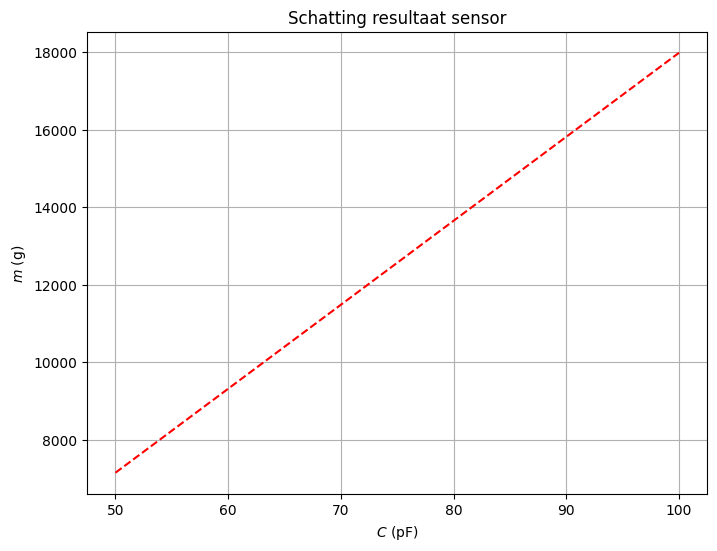

In [3]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.


A = 0.01 * 0.01
g = 9.81
e_r = 1.5

# Konden formule niet werkend krijgen met fit binnen de tijd
#def cnaarm(C, k, a):
#    return (-(e0 * e_r * A) / (g * C * 10**-12) + a / g) * k

def cnaarm(x, a, b):
    return a * x + b

x = np.linspace(50,100,10000) # (pF) begint op 17 pF 
y = (x - 17) * (1018.2 / 4.7) 

plt.figure(figsize=(8,6))
plt.plot(x,y,'r--')
plt.title("Schatting resultaat sensor")
plt.xlabel("$C$ (pF)")
plt.ylabel("$m$ (g)")
plt.grid()
plt.show()

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 17 | 85 mV |
| gemiddelde capaciteit| 66 | 700 mV |
| maximale capaciteit| 149 |1500 mV |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](Foto_opstelling_1.jpeg)
![meting 2](Foto_opstelling_2.jpeg)

## Opdracht 7: Plot de kalibratiegrafiek.

[   337.44963998 -21441.43347496]


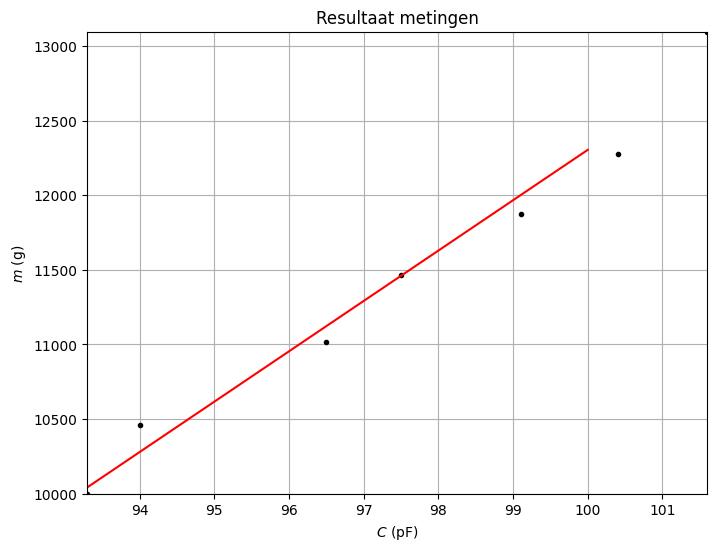

In [4]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.

# Meting scope: m = 558 + 460.2 V_out  Vpp = 218 mV 

C = np.array([93.3,94.0,96.5,97.5,99.1,100.4,101.6])
m = np.array([10000,10460.2,11018.2,11463.8,11875.8,12272.8,13094.8])

var, cov = curve_fit(cnaarm, C, m)

print(var)

x_fit = np.linspace(50,100,10000)
y_fit = cnaarm(x_fit,var[0],var[1])

plt.figure(figsize=(8,6))
plt.plot(C,m,'k.')
plt.plot(x_fit, y_fit,'r-')
plt.title("Resultaat metingen")
plt.xlabel("$C$ (pF)")
plt.ylabel("$m$ (g)")
plt.xlim(np.min(C),np.max(C))
plt.ylim(np.min(m),np.max(m))
plt.grid()
plt.show()

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* dunere spons voor meer accurate metingen op lagere massa's.
* Andere stof die geen lucht toe laat, voor minder onverwachte variabele binnen de metingen.

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![meting 1](Foto_opstelling_1.jpeg)

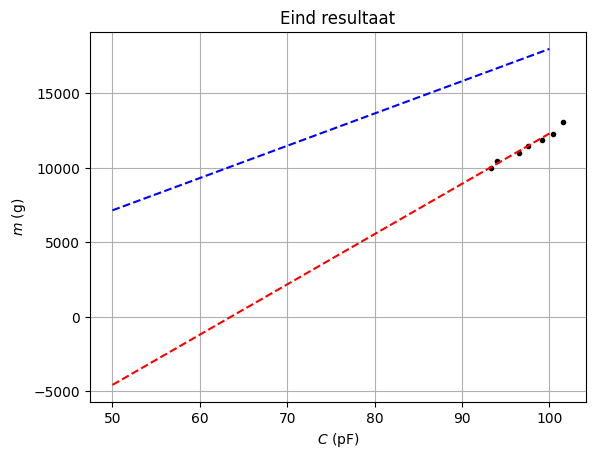

In [5]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbijplt.figure(figsize=(8,6))
plt.plot(C,m,'k.')
plt.plot(x_fit, y_fit,'r--')
plt.plot(x,y,'b--')
plt.title("Eind resultaat")
plt.xlabel("$C$ (pF)")
plt.ylabel("$m$ (g)")
plt.grid()
plt.show()

## Opdracht 10: Vul hieronder de conclusie in.

1. De sensor is niet compleet perfect, maar meet wel wat we willen weten.
2. De verbeteringen hebben gezorgd dat de sensor wel werkt, zo was er eerst door oxidatie. Dit wegschuren heeft het velen malen beter gemaakt.
3. Het capaciteit model en uitwijking model zijn niet perfect, en hierdoor is het niet perfect. Voor in de veerconstante forumule, door de lucht binnen de spons en door de onvoorspelbare gedrag van de spons is het niet passend. Zeker voor de fit function.
4. Ja, we hebben vlakke platen, waar de stroom door beide en de afstand er tussen moet lopen. Er zit een bekende stof tussen de platen, en deze neemt linear af.

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

In [6]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

e0 = 8.854e-12 

def vlakke_plaat(e_r, A, d):
    output = (e0 * e_r) * A / d * 10**12
    return output

C = [vlakke_plaat(2, 10e-2 * 10e-2, 2e-3),vlakke_plaat(4, 10e-2 * 10e-2, 2e-3)]

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 31 | 101 pF | 0.5 V | 1.03 V | 205 pF |

Pas deze tekst aan: Wij gaan een sensor maken die gewicht meet door middel van hoeveel een matriaal ingedrukt wordt.

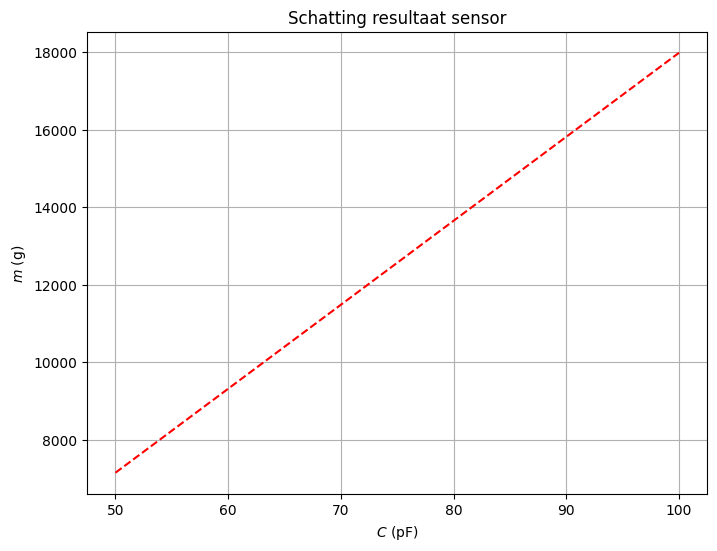

In [7]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.


A = 0.01 * 0.01
g = 9.81
e_r = 1.5

# Konden formule niet werkend krijgen met fit binnen de tijd
#def cnaarm(C, k, a):
#    return (-(e0 * e_r * A) / (g * C * 10**-12) + a / g) * k

def cnaarm(x, a, b):
    return a * x + b

x = np.linspace(50,100,10000) # (pF) begint op 17 pF 
y = (x - 17) * (1018.2 / 4.7) 

plt.figure(figsize=(8,6))
plt.plot(x,y,'r--')
plt.title("Schatting resultaat sensor")
plt.xlabel("$C$ (pF)")
plt.ylabel("$m$ (g)")
plt.grid()
plt.show()

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 17 | 85 mV |
| gemiddelde capaciteit| 66 | 700 mV |
| maximale capaciteit| 149 |1500 mV |

[   337.44963998 -21441.43347496]


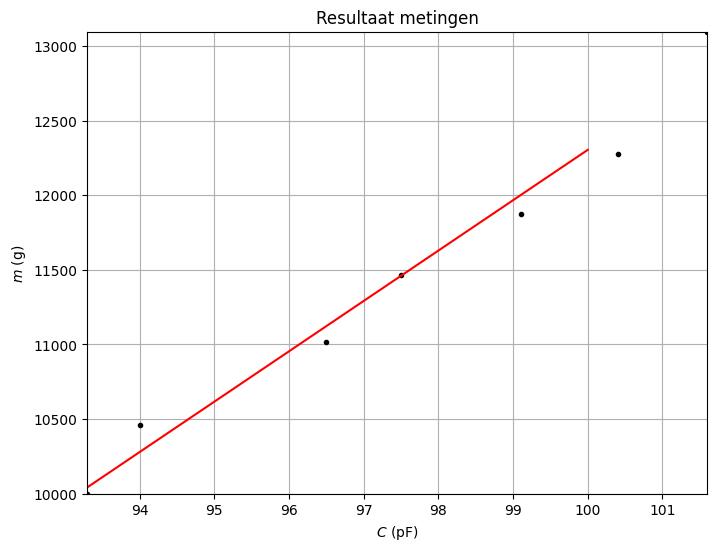

In [8]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.

# Meting scope: m = 558 + 460.2 V_out  Vpp = 218 mV 

C = np.array([93.3,94.0,96.5,97.5,99.1,100.4,101.6])
m = np.array([10000,10460.2,11018.2,11463.8,11875.8,12272.8,13094.8])

var, cov = curve_fit(cnaarm, C, m)

print(var)

x_fit = np.linspace(50,100,10000)
y_fit = cnaarm(x_fit,var[0],var[1])

plt.figure(figsize=(8,6))
plt.plot(C,m,'k.')
plt.plot(x_fit, y_fit,'r-')
plt.title("Resultaat metingen")
plt.xlabel("$C$ (pF)")
plt.ylabel("$m$ (g)")
plt.xlim(np.min(C),np.max(C))
plt.ylim(np.min(m),np.max(m))
plt.grid()
plt.show()

1. De sensor is niet compleet perfect, maar meet wel wat we willen weten.
2. De verbeteringen hebben gezorgd dat de sensor wel werkt, zo was er eerst door oxidatie. Dit wegschuren heeft het velen malen beter gemaakt.
3. Het capaciteit model en uitwijking model zijn niet perfect, en hierdoor is het niet perfect. Voor in de veerconstante forumule, door de lucht binnen de spons en door de onvoorspelbare gedrag van de spons is het niet passend. Zeker voor de fit function.
4. Ja, we hebben vlakke platen, waar de stroom door beide en de afstand er tussen moet lopen. Er zit een bekende stof tussen de platen, en deze neemt linear af.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

<img src="Opstelling_eigen_condensator.jpeg" alt="schets student 1" width="400"/>

![scope meting 1](Foto_eigen_plaatcondensator.jpeg)
![scope meting 2](Meting_eigen_plaatcondensator.jpeg)

Pas deze tekst aan: Wij gaan een sensor maken die gewicht meet door middel van hoeveel een matriaal ingedrukt wordt.

![uitgewerkte schets](Eind_schets.jpeg)

Een stuk 0.7 cm dikke spons (in druk baar tot ongeveer 1 mm) wordt ingedrukt tussen twee metalen platen, die allemaal 10 cm bij 10 cm zijn. Ook ligt er een karton plaatje van 1 mm dik en 10 cm bij 10 cm, om geleiding te voorkomen tussen het gewicht en de platen. De spons zal naar schatting ongeveer afnemen in dikte met 1 mm per 548 g gewicht die er op gelegd wordt. Hierdoor veranderd de C met 3 pF. De range van dit gewicht zal wel moeten liggen tussen 10000 g en 100000 g.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 17 | 85 mV |
| gemiddelde capaciteit| 66 | 700 mV |
| maximale capaciteit| 149 |1500 mV |

![meting 1](Foto_opstelling_1.jpeg)
![meting 2](Foto_opstelling_2.jpeg)

1. De sensor is niet compleet perfect, maar meet wel wat we willen weten.
2. De verbeteringen hebben gezorgd dat de sensor wel werkt, zo was er eerst door oxidatie. Dit wegschuren heeft het velen malen beter gemaakt.
3. Het capaciteit model en uitwijking model zijn niet perfect, en hierdoor is het niet perfect. Voor in de veerconstante forumule, door de lucht binnen de spons en door de onvoorspelbare gedrag van de spons is het niet passend. Zeker voor de fit function.
4. Ja, we hebben vlakke platen, waar de stroom door beide en de afstand er tussen moet lopen. Er zit een bekende stof tussen de platen, en deze neemt linear af.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 31 | 101 pF | 0.5 V | 1.03 V | 205 pF |

![drie schetsen](Foto_drie_schetsen.jpeg)

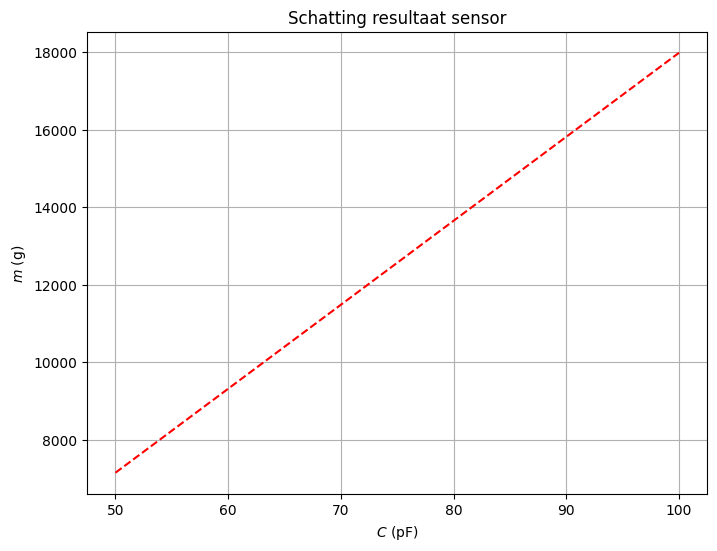

In [9]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.


A = 0.01 * 0.01
g = 9.81
e_r = 1.5

# Konden formule niet werkend krijgen met fit binnen de tijd
#def cnaarm(C, k, a):
#    return (-(e0 * e_r * A) / (g * C * 10**-12) + a / g) * k

def cnaarm(x, a, b):
    return a * x + b

x = np.linspace(50,100,10000) # (pF) begint op 17 pF 
y = (x - 17) * (1018.2 / 4.7) 

plt.figure(figsize=(8,6))
plt.plot(x,y,'r--')
plt.title("Schatting resultaat sensor")
plt.xlabel("$C$ (pF)")
plt.ylabel("$m$ (g)")
plt.grid()
plt.show()

[   337.44963998 -21441.43347496]


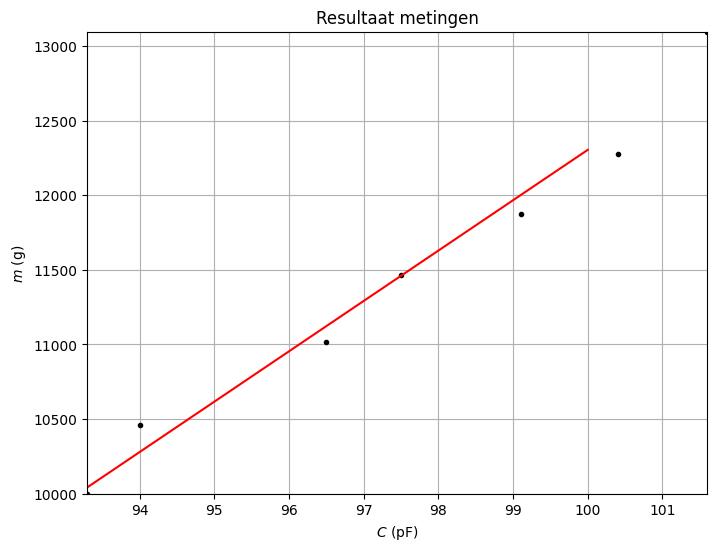

In [10]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.

# Meting scope: m = 558 + 460.2 V_out  Vpp = 218 mV 

C = np.array([93.3,94.0,96.5,97.5,99.1,100.4,101.6])
m = np.array([10000,10460.2,11018.2,11463.8,11875.8,12272.8,13094.8])

var, cov = curve_fit(cnaarm, C, m)

print(var)

x_fit = np.linspace(50,100,10000)
y_fit = cnaarm(x_fit,var[0],var[1])

plt.figure(figsize=(8,6))
plt.plot(C,m,'k.')
plt.plot(x_fit, y_fit,'r-')
plt.title("Resultaat metingen")
plt.xlabel("$C$ (pF)")
plt.ylabel("$m$ (g)")
plt.xlim(np.min(C),np.max(C))
plt.ylim(np.min(m),np.max(m))
plt.grid()
plt.show()

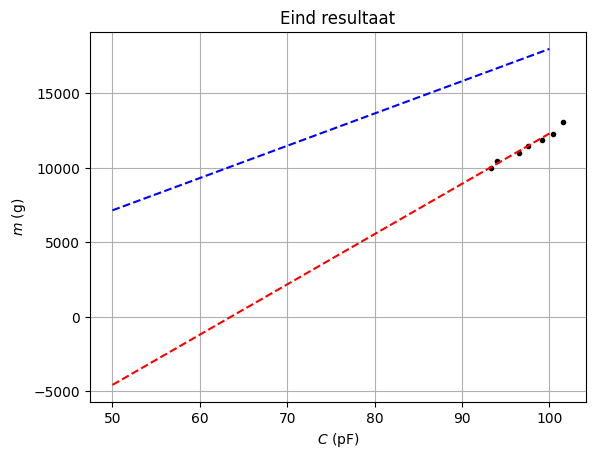

In [11]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbijplt.figure(figsize=(8,6))
plt.plot(C,m,'k.')
plt.plot(x_fit, y_fit,'r--')
plt.plot(x,y,'b--')
plt.title("Eind resultaat")
plt.xlabel("$C$ (pF)")
plt.ylabel("$m$ (g)")
plt.grid()
plt.show()

1. De sensor is niet compleet perfect, maar meet wel wat we willen weten.
2. De verbeteringen hebben gezorgd dat de sensor wel werkt, zo was er eerst door oxidatie. Dit wegschuren heeft het velen malen beter gemaakt.
3. Het capaciteit model en uitwijking model zijn niet perfect, en hierdoor is het niet perfect. Voor in de veerconstante forumule, door de lucht binnen de spons en door de onvoorspelbare gedrag van de spons is het niet passend. Zeker voor de fit function.
4. Ja, we hebben vlakke platen, waar de stroom door beide en de afstand er tussen moet lopen. Er zit een bekende stof tussen de platen, en deze neemt linear af.